# Relative strength across several Mpemba effect plots:

In [1]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
#Define variables:
theta_list = np.linspace(0,np.pi,1000)
tlist = np.linspace(0, 12, 1000)

#Hilbert space dimension:
N = 2

#Constants:
w = 1
gamma = 1

#Creatrion/annihilation operator:
sigma = qt.destroy(N)
sigma_dag = sigma.dag()

#Operators:
Ham = w*sigma_dag*sigma

#Collapse operators:

c_ops = [np.sqrt(gamma) * sigma] 


#Ground state:
ground = qt.basis(2,0) * qt.basis(2,0).dag() #Evolved state

rho_list = []

for theta in theta_list: #Independent of phi!

    x = np.sin(theta)
    y = 0
    z = np.cos(theta)

    rho = 0.5 * (
        qt.qeye(2)
        + x * qt.sigmax()
        + y * qt.sigmay()
        + z * qt.sigmaz())

    rho_list.append(rho)


results = []
for rh0 in rho_list:
    results.append(qt.mesolve(Ham,rh0,tlist,c_ops))

    
all_rho_t = [res.states for res in results] #Gives a list of all rho(t), for different theta.

In [3]:
#Define the Frobenius distance

def frobenius(rho, evolved):#Function of roh and evolved state
    
    diff = (rho - evolved)
    tr_diff = (diff.dag()*diff).tr() #Same form as eqn.
    
    return float(np.sqrt(tr_diff.real))



#Now calculate distances and calculate whether an Mpemba effect is present:
#Will use, Trace distance, frobenius, relative entropy, fidelity, bures distance, Hilbert-schmidt etc...

#Add frobenius in later, needs to be defined first...
distance_funcs = {"Trace": qt.tracedist,
                  "Frobenius": frobenius,
                  "Relative Entropy": qt.entropy_relative,
                  "Hilbert": qt.hilbert_dist,
                  "Bures": qt.bures_dist,
                  "Fidelity": qt.fidelity
                 }

#store results as a dictionary:
results = {}


#Loop over diferent distances: 
for name, dist_func in distance_funcs.items():
    Dist = []

    for rho_t in all_rho_t: #Loops over theta         
        D_t = [dist_func(rho, ground) for rho in rho_t] #Loops over time
        Dist.append(D_t)
        
    Dist = np.array(Dist)
    
    #Detect a cross over: 
    n_theta = Dist.shape[0] #Number of theta

    crossing_matrix = np.zeros((n_theta, n_theta), dtype=bool)#A true/false matrix of results to be plotted
    diff_matrix = np.zeros((n_theta, n_theta))
    time_matrix = np.zeros((n_theta, n_theta))
    strength_matrix = np.zeros((n_theta, n_theta))
    
    crossing_matrix.shape #Check its the expected shape.

    for i in range(n_theta):
        for j in range(i + 1, n_theta):#Skips repeated pairs of theta.
            diff = Dist[i] - Dist[j]

            #[:-1] ignores final data point and [1:] ignores the first. 
            #A cross between elements 2-3 will record as 2 here:
            
            #This method helps to stop zero errors, zeros will return false!
            has_crossing = np.any(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0) #Shifted data points are compared 

            crossing_matrix[i, j] = has_crossing
            crossing_matrix[j, i] = has_crossing  # symmetry
            
            
            
            
            diff_0 = Dist[i][0] - Dist[j][0]#Difference at t=0.
        
            diff_matrix[i,j] = diff_0
            diff_matrix[j,i] = diff_0 #Sign doesn't matter, will plot mod as some values may be negative. 
            
            #Time of crossing: 
            diff = Dist[i] - Dist[j]
            crossing_point = np.where(np.sign(diff[:-1]) * np.sign(diff[1:]) < 0) #Where gives precise locations
            crossing_points = crossing_point[0]#Times where it crossed

            if len(crossing_points) > 0:
                first_cross = crossing_points[0]#First cross

                crossing_time = tlist[first_cross]

                time_matrix[i,j] = crossing_time
                time_matrix[j,i] = crossing_time #Again, - values shouldn't matter here 

                strength = diff_0 / crossing_time
                strength_matrix[i,j] = np.abs(strength)
                strength_matrix[j,i] = np.abs(strength)

            else:
                time_matrix[i,j] = 0
                time_matrix[j,i] = 0

                strength_matrix[i,j] = 0
                strength_matrix[j,i] = 0

    Mpembas = crossing_matrix.astype(int) #changed True/false to 0/1 to be plotted
    
    # store result
    results[name] = {"Mpemba": Mpembas,
                     "Times": time_matrix,
                     "Strength":strength_matrix,
                     "Dist": Dist}

#results["Trace"]["Mpemba"] will give the data needed!

results["Trace"]["Mpemba"]

C:\Users\otrev\AppData\Local\Temp\ipykernel_26316\2409061139.py:50: RuntimeWarning: invalid value encountered in subtract
  diff = Dist[i] - Dist[j]
C:\Users\otrev\AppData\Local\Temp\ipykernel_26316\2409061139.py:64: RuntimeWarning: invalid value encountered in scalar subtract
  diff_0 = Dist[i][0] - Dist[j][0]#Difference at t=0.
C:\Users\otrev\AppData\Local\Temp\ipykernel_26316\2409061139.py:70: RuntimeWarning: invalid value encountered in subtract
  diff = Dist[i] - Dist[j]


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 1, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 1, 0]])

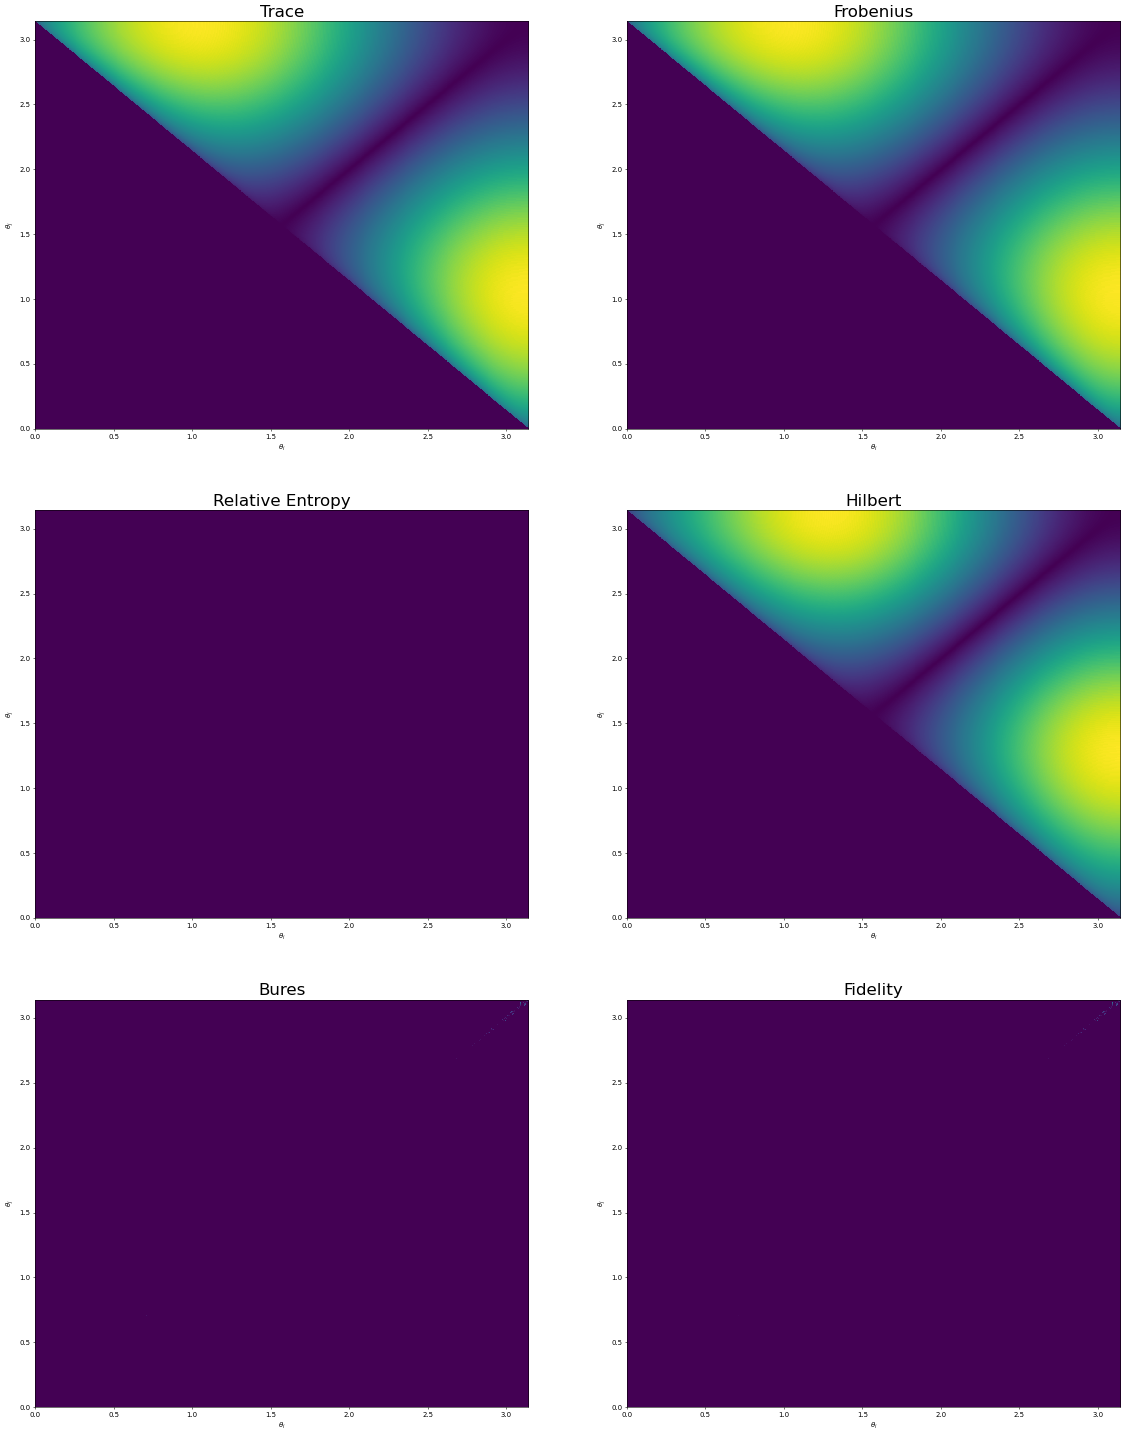

In [4]:
n_plots = len(results)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

import matplotlib
matplotlib.rcParams['figure.dpi'] = 50

from matplotlib.colors import ListedColormap


fig, axes = plt.subplots(n_rows, n_cols, figsize=(14*n_cols, 12*n_rows))
axes = axes.flatten()

for ax, (name, data) in zip(axes, results.items()):
    
    im = ax.imshow(
        data["Strength"],
        origin="lower",
        cmap="viridis",
        interpolation='nearest',
        aspect='auto',
        extent=[0, np.pi, 0, np.pi]
    )

    ax.set_title(name, fontsize=24)
    ax.set_xlabel(r"$\theta_i$")
    ax.set_ylabel(r"$\theta_j$")
    


### Find the peak Mpemba effect values:

In [9]:
#Dictionary to store max value positions for each strength:
max_positions = {}


for (name, data) in results.items():
    #Find position of the max strength val
    max_val = np.max(data["Strength"])
    max_val_pos = np.argwhere(data["Strength"] == max_val) #Finds where max matrix value is
    #Find theta values: 
    indice_1, indice_2 = max_val_pos[0][0], max_val_pos[0][1]
    theta_1, theta_2 = theta_list[indice_1], theta_list[indice_2]
    
    #Only print for an appreciable value of strength:
    if max_val > 0.05:
        
        #Stores position/value
        #Stores all equal max points to plot
        pairs = [(theta_list[index[0]], theta_list[index[1]]) for index in max_val_pos]
        max_positions[name] = {"pairs": pairs, "max_val": max_val}
        
        #Show data:
        print(f"{name}: max strength = {max_val:.3f}")
        for t1, t2 in pairs:
            print(f"  theta_1={t1/np.pi}π, theta_2={t2/np.pi}π")


Trace: max strength = 0.313
  theta_1=0.3333333333333333π, theta_2=1.0π
  theta_1=1.0π, theta_2=0.3333333333333333π
Frobenius: max strength = 0.443
  theta_1=0.3333333333333333π, theta_2=1.0π
  theta_1=1.0π, theta_2=0.3333333333333333π
Hilbert: max strength = 0.972
  theta_1=0.40840840840840836π, theta_2=1.0π
  theta_1=1.0π, theta_2=0.40840840840840836π


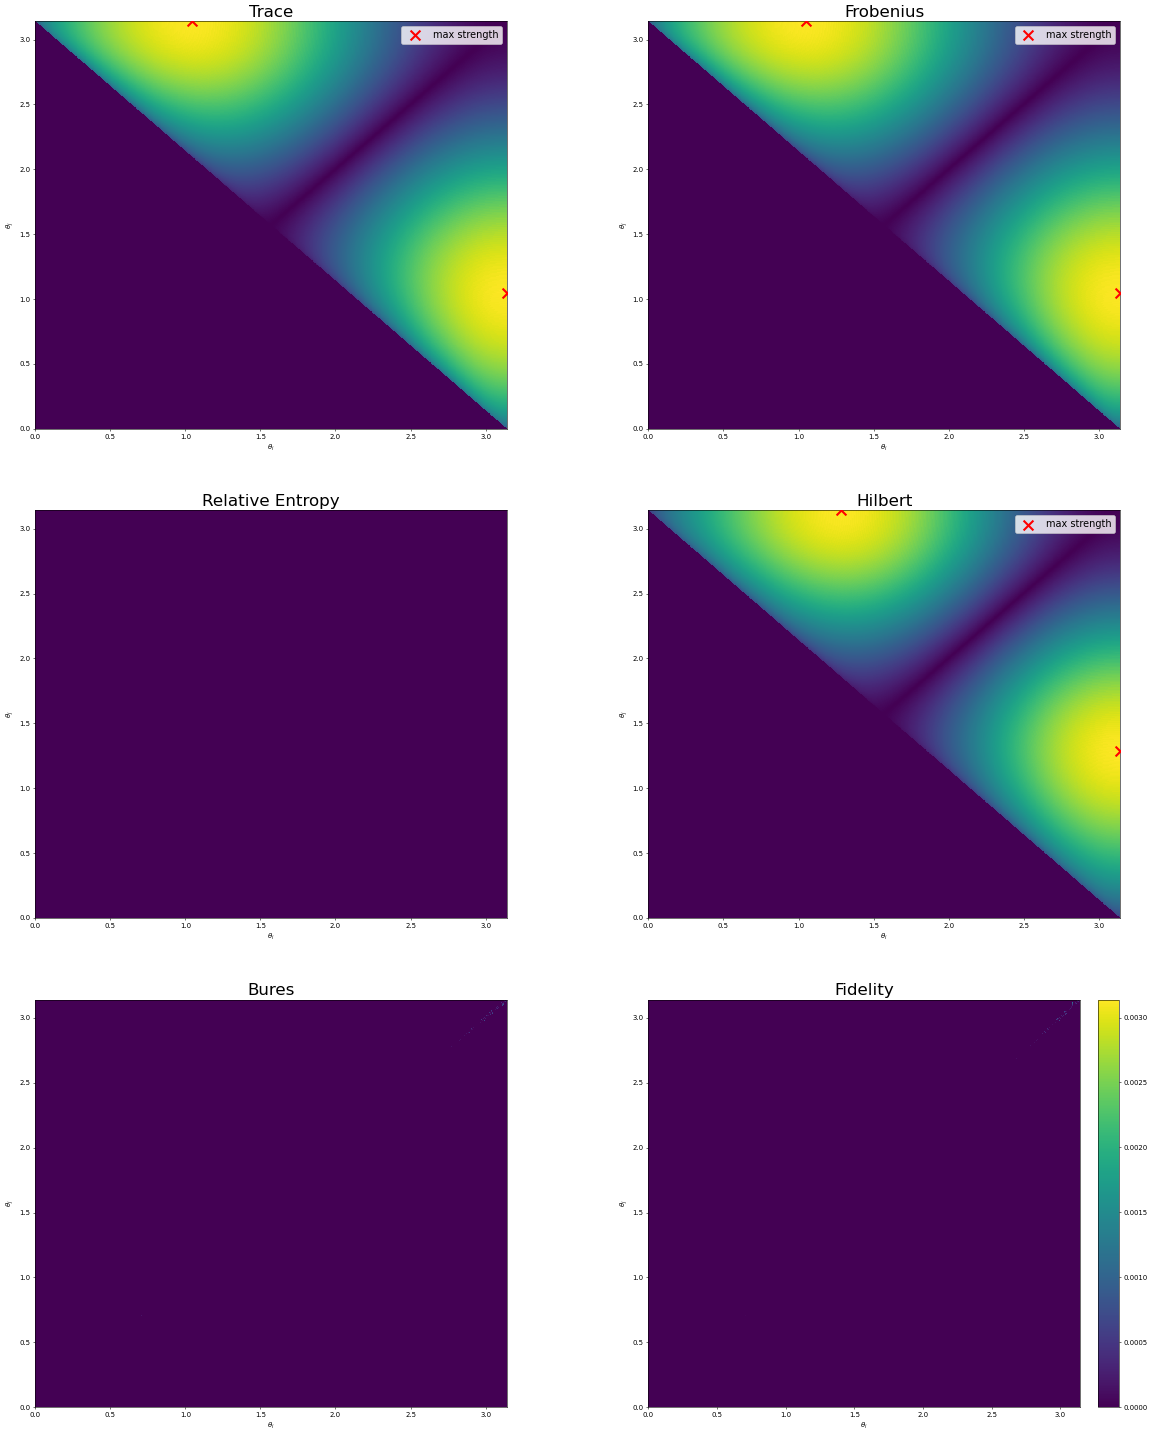

In [6]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14*n_cols, 12*n_rows))
axes = axes.flatten()

for ax, (name, data) in zip(axes, results.items()):
    
    im = ax.imshow(
        data["Strength"],
        origin="lower",
        cmap="viridis",
        interpolation='nearest',
        aspect='auto',
        extent=[0, np.pi, 0, np.pi]
    )

    ax.set_title(name, fontsize=24)
    ax.set_xlabel(r"$\theta_i$")
    ax.set_ylabel(r"$\theta_j$")
    
    if name in max_positions:
        #This allows the loop to only set the legend once for this plot!
        first = True
        for theta1, theta2 in max_positions[name]["pairs"]: #Loops over all points
            
            ax.scatter(theta2, theta1, color='red', s=200, marker='x',
                      linewidths=3, label='max strength' if first else "_nolegend_", zorder=5)
            
            ax.legend(fontsize=14)
            first = False

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)

plt.subplots_adjust(wspace=0.3)

# Test analytical condition:

$\sin^2\left(\frac{\theta_1}{2}\right) + \sin^2\left(\frac{\theta_2}{2}\right) > 1$

In [7]:
#Set up grid for results:
predictions =  np.zeros((n_theta, n_theta), dtype=bool)

for i in range(n_theta):
        for j in range(i + 1, n_theta):
            
            #Define thetas 
            theta1 = theta_list[i]
            theta2 = theta_list[j]
        
            #Condition to be satisfied:
            condition = (np.sin(theta1/2))**2 + (np.sin(theta2/2))**2 >1

            #Applying condition 
            if condition == True:
                predictions[i, j] = True
                predictions[j, i] = True
     
#Check its of the correct form
predictions

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False,  True],
       [False, False, False, ..., False,  True,  True],
       ...,
       [False, False, False, ..., False,  True,  True],
       [False, False,  True, ...,  True, False,  True],
       [False,  True,  True, ...,  True,  True, False]])

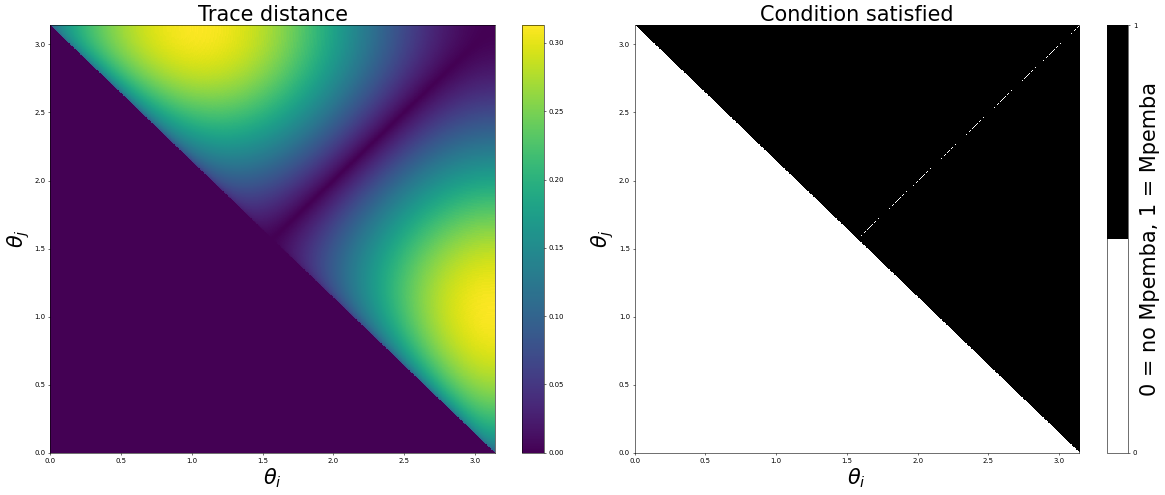

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "black"])


#Trace strength plot
im0 = axes[0].imshow(
    results["Trace"]["Strength"],
    origin="lower",
    cmap="viridis",
    interpolation="nearest",
    aspect="auto",
    extent=[0, np.pi, 0, np.pi])

axes[0].set_title("Trace distance", fontsize=30)
axes[0].set_xlabel(r"$\theta_i$", fontsize=30)
axes[0].set_ylabel(r"$\theta_j$", fontsize=30)
fig.colorbar(im0, ax=axes[0])

# --- 2. Predictions map ---
im1 = axes[1].imshow(
    predictions,
    origin="lower",
    cmap=cmap,
    interpolation="nearest",
    aspect="auto",
    extent=[0, np.pi, 0, np.pi])

axes[1].set_title("Condition satisfied", fontsize=30)
axes[1].set_xlabel(r"$\theta_i$", fontsize=30)
axes[1].set_ylabel(r"$\theta_j$", fontsize=30)

#Colour bar:
cbar = fig.colorbar(im1, ax=axes[1], ticks=[0, 1], label="0 = no Mpemba, 1 = Mpemba")
cbar.set_label("0 = no Mpemba, 1 = Mpemba", fontsize=30)


plt.tight_layout()
plt.show()

## Bloch sphere plot for largest relative Mpemba strength:

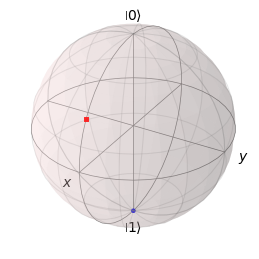

In [23]:
#Importing the Bloch sphere object:
Bloch = qt.Bloch()

#Theta and phi values
theta_list = np.array([np.pi,np.pi/3]) #Strongest Mpe,ba effect pair.
phi = 0


for theta in theta_list:
    
    #Eqns for x/y/z points in spherical coords.
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    #Eqn for surface of Bloch sphere. 
    rho_b = 0.5 * (qt.qeye(2)
        + x * qt.sigmax()
        + y * qt.sigmay()
        + z * qt.sigmaz())

    #
    x_s = qt.expect(qt.sigmax(), rho_b) #Expect() gives only real values.
    y_s = qt.expect(qt.sigmay(), rho_b)
    z_s = qt.expect(qt.sigmaz(), rho_b)

    Bloch.add_points([x_s, y_s, z_s])

Bloch.show()

## Show their time evolution: